In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import colors

from matplotlib.axes import Axes
import numpy as np
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FixedLocator, NullLocator)
from collections import Counter

from hubo_qaoa.utils.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [2]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingall.precompute.0.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)
list(res.keys())

['test_N2_W2',
 'trivial',
 'test_N3_W4',
 'test_N4_W5',
 'test_N7_W2',
 'test_N7_W3',
 'test_N7_W4',
 'test_N8_W2',
 'test_N8_W3',
 'test_N8_W5',
 'test_N8_W6']

In [33]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplinggrid.precompute.120.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)
list(res.keys())

['test_N2_W2',
 'trivial',
 'test_N3_W4',
 'test_N4_W5',
 'test_N7_W2',
 'test_N7_W3',
 'test_N7_W4',
 'test_N8_W2',
 'test_N8_W3']

In [36]:
res['test_N7_W4']['rzz']['circuit'].count_ops()

OrderedDict([('cx', 1339), ('rzz', 510), ('rz', 207), ('swap', 107)])

In [49]:
def plot(ax, filename, maxdb, maxdg, shots, show_cbar=False):
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.shots{shots}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    delta_b_fixed = res['delta_b_fixed'] 
    delta_g_fixed = res['delta_g_fixed'] 
    rescaling = np.array(res['rescaling'])
    ps = np.array(res['ps'])
    print(rescaling)
    print(np.min(energies))
    
    def log_edges(x):
        return np.concatenate([
            x[:1] / np.sqrt(x[1] / x[0]),
            np.sqrt(x[:-1] * x[1:]),
            x[-1:] * np.sqrt(x[-1] / x[-2])
        ])

    ps_edges = log_edges(ps)
    rescaling_edges = log_edges(rescaling)
    
    cmap = plt.get_cmap()
    cmap.set_over('white')
    
    im = ax.pcolormesh(
        ps_edges,
        rescaling_edges,
        energies.T,      # transpose so shape is (Ny, Nx)
        shading='auto',
        cmap=cmap,
        vmin=0,
        vmax=2
    )

    ax.set_xscale('log')
    xticks = sorted(ps)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(x) for x in xticks])
    ax.xaxis.set_minor_locator(NullLocator())

    ax.set_yscale('log')

    ax.set_xlabel('p')
    # ax.set_ylabel('rescaling')

    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.set_label('Energy')

    
    ax.set_ylabel(r'$\Delta_\beta / \Delta_{\beta,\text{fixed}} = \Delta_\gamma / \Delta_{\gamma,\text{fixed}}$')
    ax.set_title(f'{filename}, $\\Delta_\\beta = {delta_b_fixed}$, $\\Delta_\\gamma = {delta_g_fixed}$')
    return ax

0.0
0.0
0.0
0.0
0.0
-7.105427357601002e-15


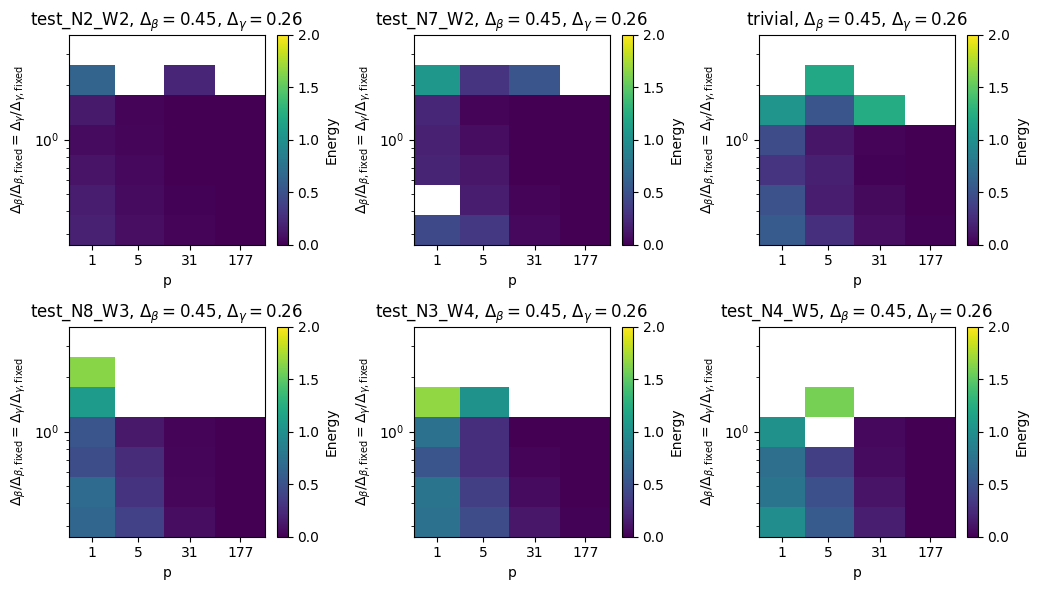

In [31]:
fig, axs = plt.subplots(2, 3)
plot(axs[0, 0], 'test_N2_W2', 0.45, 0.26, 4000, True)
plot(axs[0, 1], 'test_N7_W2', 0.45, 0.26, 4000, True)
plot(axs[0, 2], 'trivial', 0.45, 0.26, 4000, True)
plot(axs[1, 0], 'test_N8_W3', 0.45, 0.26, 4000, True)
plot(axs[1, 1], 'test_N3_W4', 0.45, 0.26, 4000, True)
plot(axs[1, 2], 'test_N4_W5', 0.45, 0.26, 4000, True)

fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [32]:
10 ** 2.25

177.82794100389228

In [69]:
def plot_dist(
    axs: list[Axes], 
    filename, copy_numbers, maxdb, maxdg, shots,
    p = 6, db = 0.1, dg = 4.0,
    normalise=True
) -> list[Axes]:
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
    hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.shots{shots}.pkl', 'rb') as f:
        res = pickle.load(f)
        
    
    samples_dict: dict[tuple, str] = res['samples_dict']
    energies = res['energies']
    delta_b_fixed = res['delta_b_fixed'] 
    delta_g_fixed = res['delta_g_fixed']
    iters = ['0', '5', '9']
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    
    keys = samples_dict.keys()
    true_key = None
    for key in keys:
        if key[0] == p and np.abs(key[1] * db - delta_b_fixed)**2 < 0.0005 and np.abs(key[1] * dg - delta_g_fixed)**2 < 0.0005:
            true_key = key
            break
    if true_key is None:
        raise Exception('Could not find key')
    print(filename, true_key)

    cutoff=25
    ax = axs[0]
    random_samples = np.random.choice(('0', '1'), (shots, n*T))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(norm * (evaluate_sparse_pauli_samples(rand_samples, hamiltonian)), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/shots]*len(rand_vals), rwidth=1, log=True)
    ax.set_xlim(0, cutoff)
    ax.set_ylim(10**-3, 10**0)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = -1', ha='right', va='top', transform=ax.transAxes)
    
    for i in range(1, len(axs)):
        ax = axs[i]
        counter = Counter(samples_dict[true_key][i-1])
        
        evals = np.round(norm * (evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian)), 2)
        energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
        sample_vals = np.array([x for xs in energies for x in xs])
        print([count for idx, count in enumerate(counter.values()) if evals[idx] < 1e-5])
        print(np.mean(sample_vals))

        ax.hist(sample_vals, bins=range(cutoff+1), weights=[1/shots]*len(sample_vals), rwidth=1, log=True)
        ax.set_xlim(0, cutoff)
        ax.set_ylim(10**-3, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1]}', ha='right', va='top', transform=ax.transAxes)

    return axs

Keeping constraints at times: [0]
test_N2_W2 (5, np.float64(0.6812920690579612))
Keeping constraints at times: [0]
test_N7_W2 (5, np.float64(0.6812920690579612))
Keeping constraints at times: [0 1]
trivial (5, np.float64(0.6812920690579612))
Keeping constraints at times: [1 0]
test_N8_W3 (5, np.float64(0.6812920690579612))
Keeping constraints at times: [1 0 2]
test_N3_W4 (5, np.float64(0.6812920690579612))
Keeping constraints at times: [0 1 3 2]
test_N4_W5 (5, np.float64(0.6812920690579612))


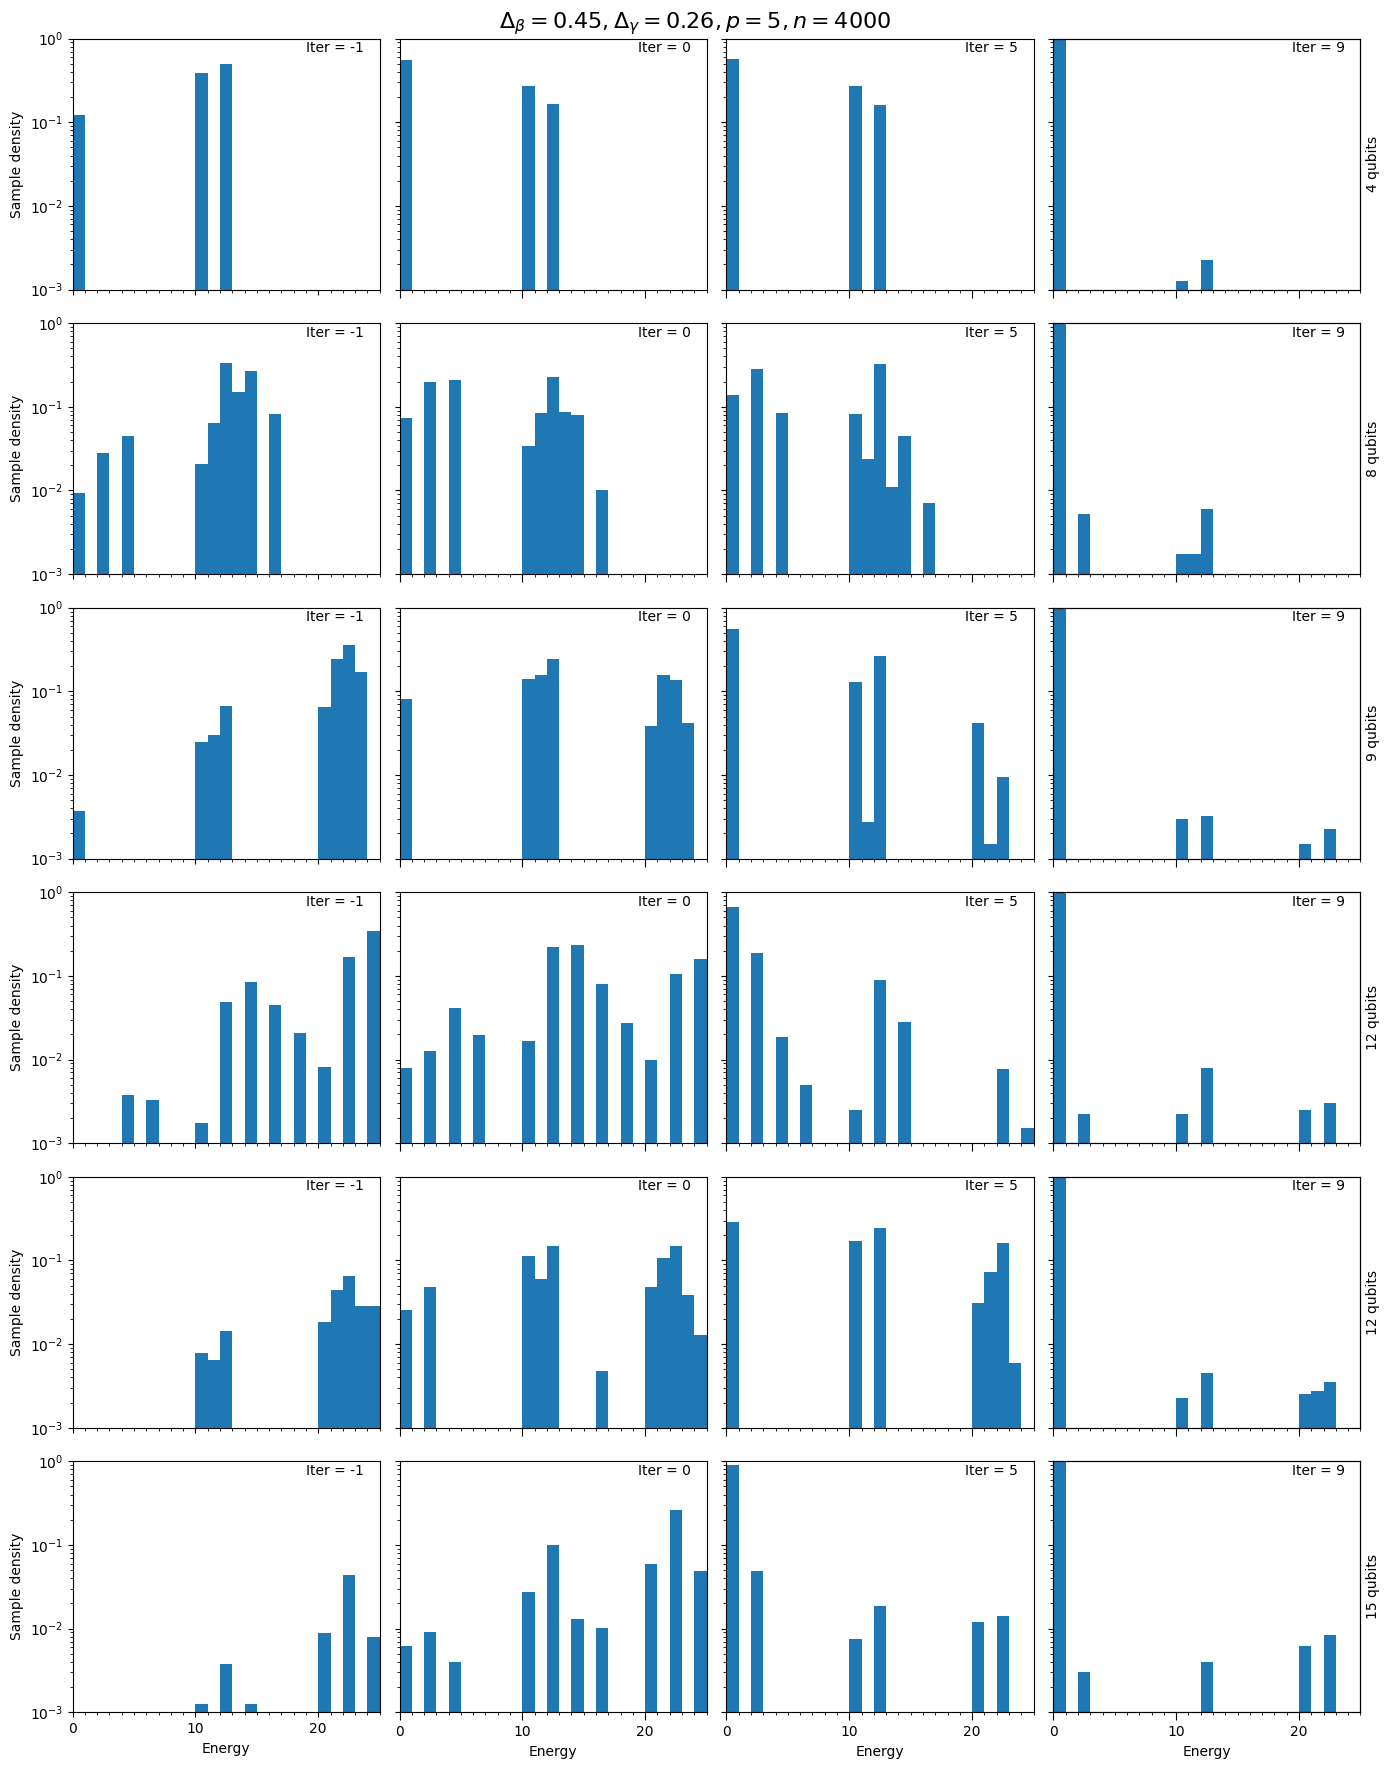

In [34]:
fig, axs = plt.subplots(6, 4, sharey='row', sharex='col')
p = 5
db = 0.45
dg = 0.26
rescale = 10**(0.133)
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]
axs5 = axs[5, :]


axs0 = plot_dist(axs0, 'test_N2_W2', [1,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
axs1 = plot_dist(axs1, 'test_N7_W2', [1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
axs2 = plot_dist(axs2, 'trivial', [1,1,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
axs3 = plot_dist(axs3, 'test_N8_W3', [1,1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
axs4 = plot_dist(axs4, 'test_N3_W4', [2,1,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
axs5 = plot_dist(axs5, 'test_N4_W5', [2,1,1,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [4, 8, 9, 12, 12, 15]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {db}, \\Delta_\\gamma = {dg}, p = {p}, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()
# fig.set_tight_layout('tight')


Keeping constraints at times: [0]
test_N2_W2 (31, np.float64(1.0))
Keeping constraints at times: [0]
test_N7_W2 (31, np.float64(1.0))
Keeping constraints at times: [0 1]
trivial (31, np.float64(1.0))
Keeping constraints at times: [1 0]
test_N8_W3 (31, np.float64(1.0))
Keeping constraints at times: [0 2 1]
test_N3_W4 (31, np.float64(1.0))
Keeping constraints at times: [1 2 0 3]
test_N4_W5 (31, np.float64(1.0))


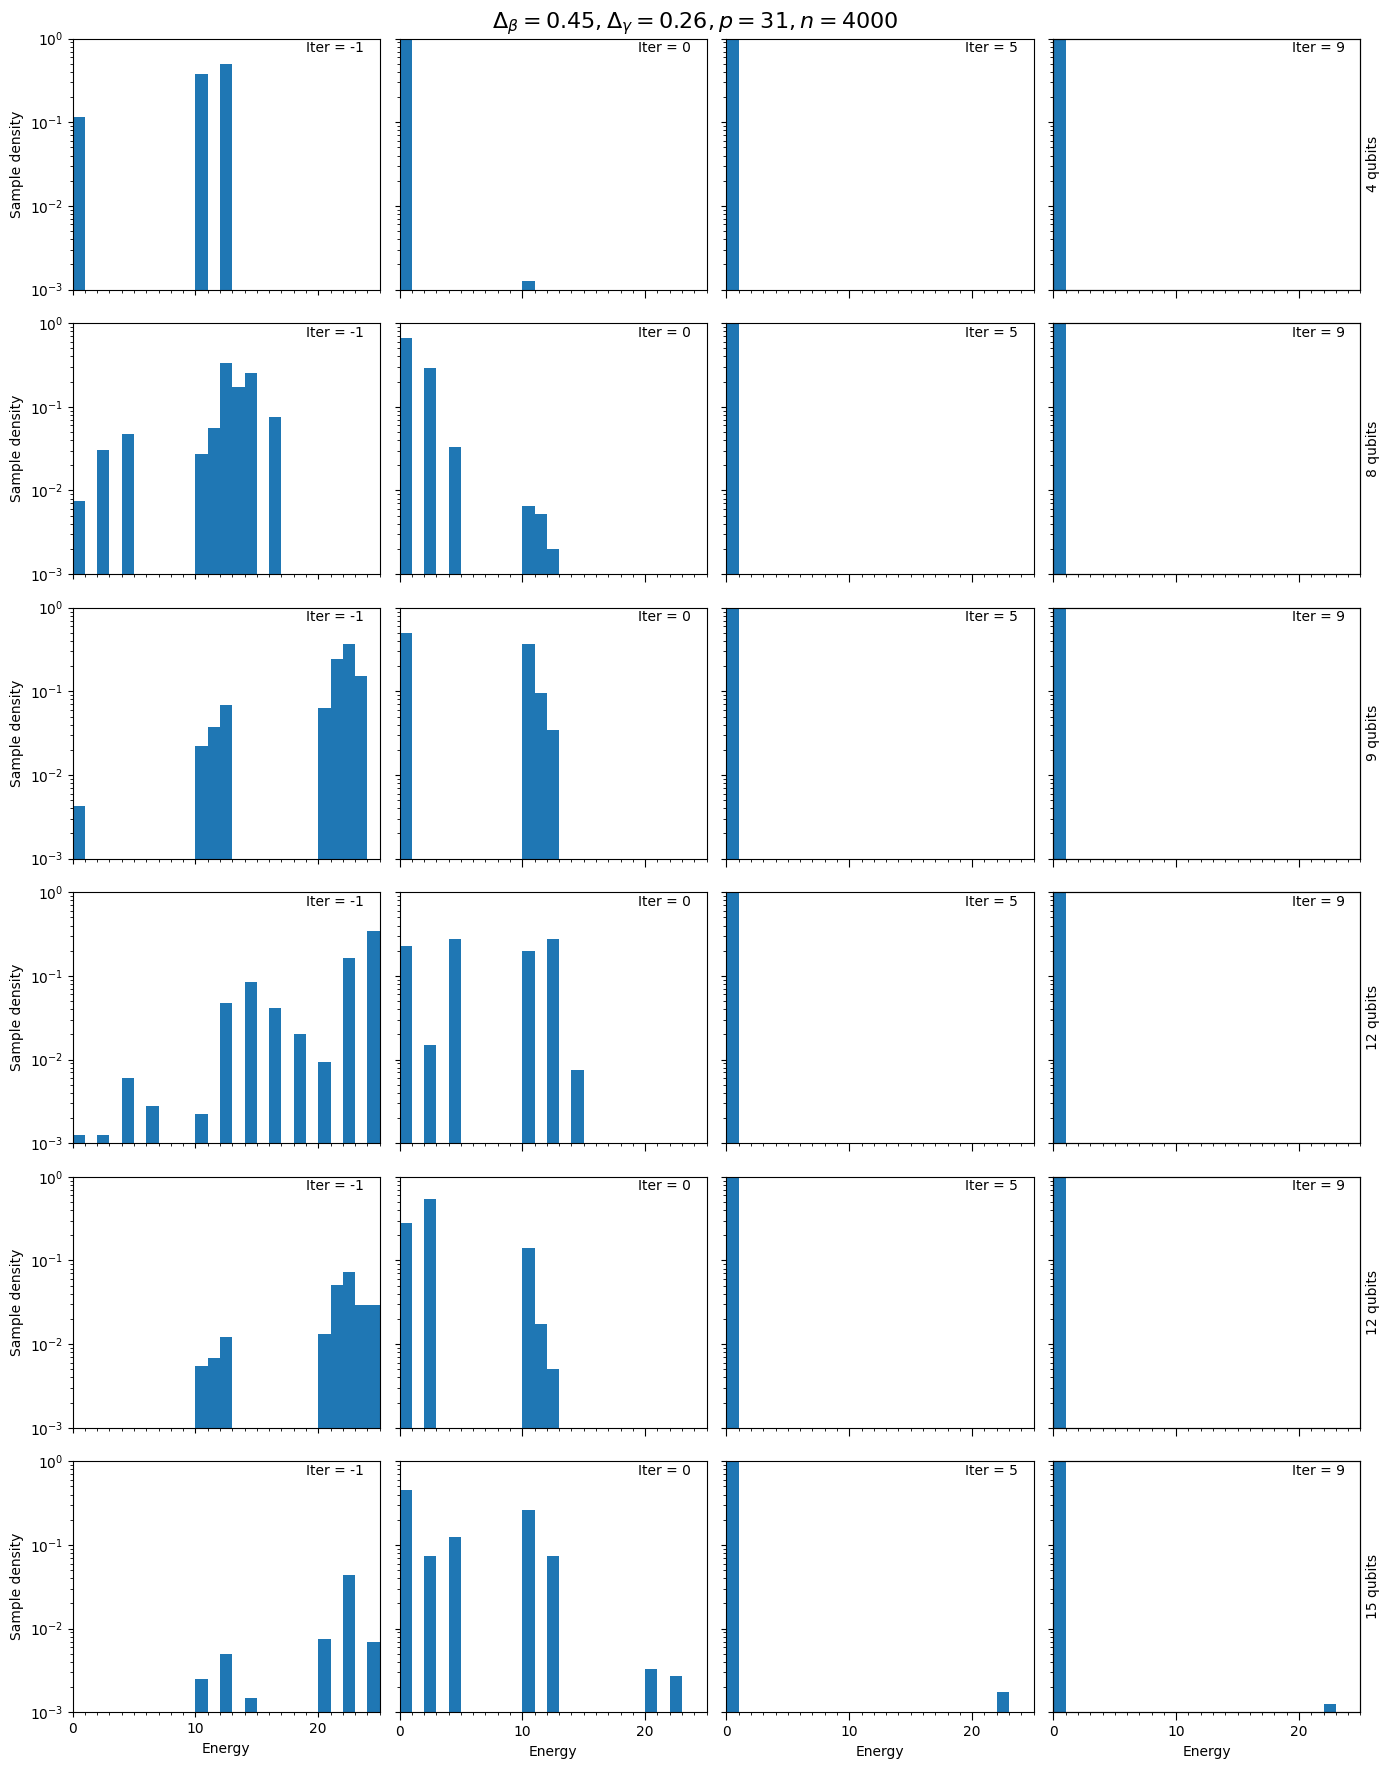

In [35]:
fig, axs = plt.subplots(6, 4, sharey='row', sharex='col')
p = 31
db = 0.45
dg = 0.26
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]
axs5 = axs[5, :]


axs0 = plot_dist(axs0, 'test_N2_W2', [1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs1 = plot_dist(axs1, 'test_N7_W2', [1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs2 = plot_dist(axs2, 'trivial', [1,1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs3 = plot_dist(axs3, 'test_N8_W3', [1,1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs4 = plot_dist(axs4, 'test_N3_W4', [2,1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)
axs5 = plot_dist(axs5, 'test_N4_W5', [2,1,1,1], db, dg, 4000, p=p, db=db, dg=dg, normalise=False)


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [4, 8, 9, 12, 12, 15]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {db}, \\Delta_\\gamma = {dg}, p = {p}, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()
# fig.set_tight_layout('tight')


In [64]:
np.logspace(-0.5, 0.2, 8, base=10)


array([0.31622777, 0.39810717, 0.50118723, 0.63095734, 0.79432823,
       1.        , 1.25892541, 1.58489319])

[0.31622777 0.39810717 0.50118723 0.63095734 0.79432823 1.
 1.25892541 1.58489319]
0.0025
[0.31622777 0.39810717 0.50118723 0.63095734 0.79432823 1.
 1.25892541 1.58489319]
0.0025
[0.31622777 0.39810717 0.50118723 0.63095734 0.79432823 1.
 1.25892541 1.58489319]
0.01275


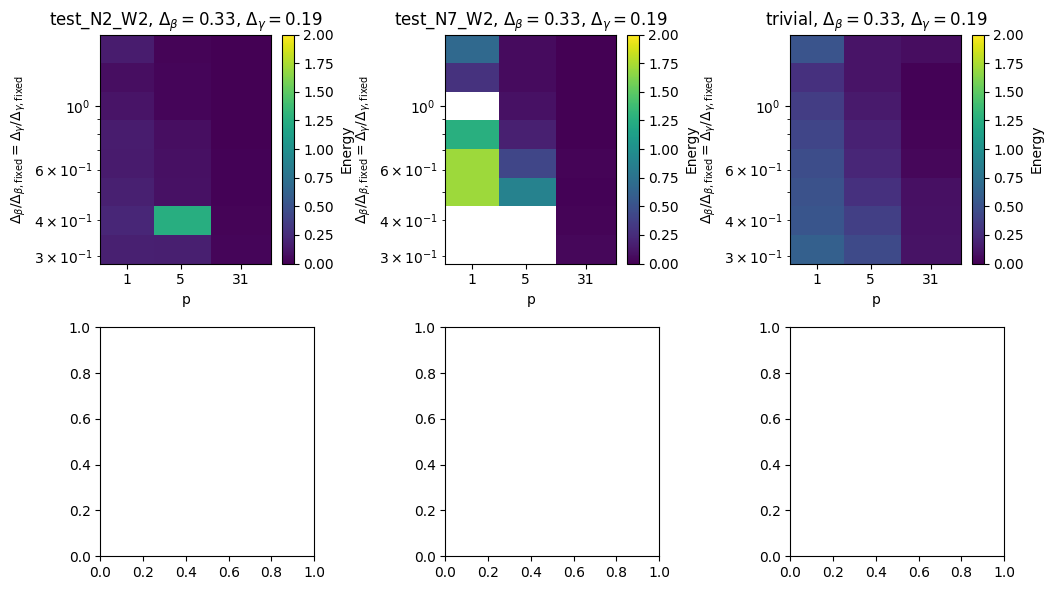

In [66]:
fig, axs = plt.subplots(2, 3)
plot(axs[0, 0], 'test_N2_W2', 0.33, 0.19, 4000, True)
plot(axs[0, 1], 'test_N7_W2', 0.33, 0.19, 4000, True)
plot(axs[0, 2], 'trivial', 0.33, 0.19, 4000, True)
# plot(axs[1, 0], 'test_N8_W3', 0.33, 0.19, 4000, True)
# plot(axs[1, 1], 'test_N3_W4', 0.33, 0.19, 4000, True)
# plot(axs[1, 2], 'test_N4_W5', 0.33, 0.19, 4000, True)

fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

Keeping constraints at times: [0]
test_N2_W2 (1, np.float64(0.9999999999999999))
[531, 536]
8.0895
[1997, 37]
5.4115
[3962]
0.103
Keeping constraints at times: [0]
test_N7_W2 (1, np.float64(0.9999999999999999))
[44, 38]
10.535
[73, 64]
9.91525
[885, 1]
5.4845
Keeping constraints at times: [0 1]
trivial (1, np.float64(0.9999999999999999))
[49, 39]
18.2360295993876
[2380, 3]
5.6006006006006
[3903]
0.35575


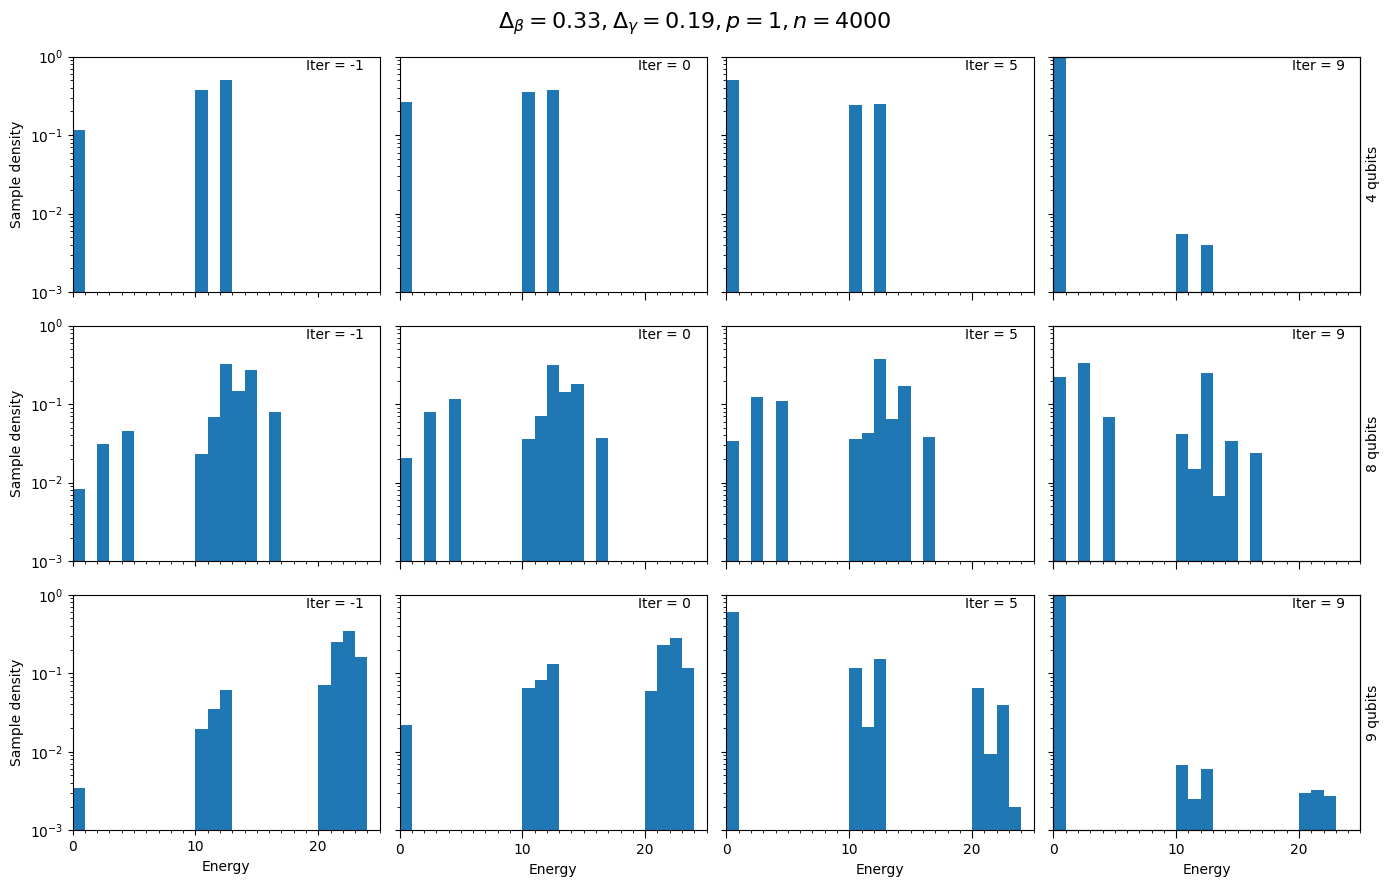

In [71]:
fig, axs = plt.subplots(3, 4, sharey='row', sharex='col')
p = 1
db = 0.33
dg = 0.19
rescale = 10**(0)
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]
# axs5 = axs[5, :]


axs0 = plot_dist(axs0, 'test_N2_W2', [1,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
axs1 = plot_dist(axs1, 'test_N7_W2', [1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
axs2 = plot_dist(axs2, 'trivial', [1,1,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
# axs3 = plot_dist(axs3, 'test_N8_W3', [1,1,0,0,0,0,0,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
# axs4 = plot_dist(axs4, 'test_N3_W4', [2,1,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)
# axs5 = plot_dist(axs5, 'test_N4_W5', [2,1,1,1], db, dg, 4000, p=p, db=db*rescale, dg=dg*rescale, normalise=False)


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [4, 8, 9, 12, 12, 15]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {db}, \\Delta_\\gamma = {dg}, p = {p}, n = 4000$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()
# fig.set_tight_layout('tight')


In [2]:
db_fixed, dg_fixed = 0.75, 0.30
rescale = 10**(0.0)

shots = 4000
ps = [1,3,5]
iters=range(0,10,2)
max_beta_T = 0.15
eps=0.15
alpha=1.0
filename='test_N8_W6'
copy_numbers=[1,1,0,1,1,1,0,1]

filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
hamiltonian = hamiltonian * norm
num_qubits: int = hamiltonian.num_qubits

try:
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{shots}.betaT{max_beta_T}.eps{eps}.alpha{alpha}.pkl', 'rb') as f:
        res = pickle.load(f)
except Exception:
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.ps{ps[-1]}.shots{shots}.betaT{max_beta_T}.eps{eps}.alpha{alpha}.pkl', 'rb') as f:
        res = pickle.load(f) 

Keeping constraints at times: [3 1 2 4 0]


In [23]:
def get_path(sample):
    nodes = [sample[n*i:n*(i+1)][::-1] for i in range(T)]
    return [list(graph.nodes)[int(node, 2)] for node in nodes]
    

In [32]:
c = Counter(res['samples_dict'][(1,1)][1]).most_common(20)
evals = evaluate_sparse_pauli_samples([x[0] for x in c], hamiltonian)
[(c[i][1], get_path(c[i][0]), evals[i]) for i in range(len(c))]

[(534, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(2.0)),
 (139, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(2.0)),
 (98, ['u7_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(12.0)),
 (43, ['u6_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(4.0)),
 (38, ['u7_-', 'u5_-', 'u4_-', 'u7_-', 'u2_-', 'u0_-'], np.float64(24.0)),
 (32, ['u7_-', 'u5_-', 'u4_-', 'u3_+', 'u2_-', 'u0_-'], np.float64(22.0)),
 (32, ['u7_-', 'u5_-', 'u0_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(24.0)),
 (31, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u3_-'], np.float64(14.0)),
 (29, ['u1_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(12.0)),
 (27, ['u5_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(14.0)),
 (26, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u0_+', 'u1_-'], np.float64(20.0)),
 (23, ['u7_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(12.0)),
 (23, ['u3_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(14.0)),
 (23, ['u7_-', 'u4_-', 'u4

In [28]:
c = Counter(res['samples_dict'][(1,1)][8]).most_common(20)
evals = evaluate_sparse_pauli_samples([x[0] for x in c], hamiltonian)
[(c[i][1], get_path(c[i][0]), evals[i]) for i in range(len(c))]

[(327, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(2.0)),
 (324, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(2.0)),
 (69, ['u7_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(12.0)),
 (45, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u3_-'], np.float64(14.0)),
 (39, ['u7_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(12.0)),
 (30, ['u6_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(4.0)),
 (30, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u0_+', 'u1_-'], np.float64(20.0)),
 (28, ['u7_-', 'u5_-', 'u4_+', 'u3_-', 'u2_-', 'u1_-'], np.float64(22.0)),
 (26, ['u6_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(4.0)),
 (26, ['u7_-', 'u5_-', 'u4_-', 'u7_-', 'u2_-', 'u1_-'], np.float64(24.0)),
 (26, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u6_-'], np.float64(14.0)),
 (25, ['u7_-', 'u4_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(14.0)),
 (24, ['u5_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(14.0)),
 (23, ['u7_-', 'u5_-', 'u4_